In [1]:
%load_ext autoreload
%autoreload 2

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
from scipy.stats import chi2

from tdastro.astro_utils.mag_flux import mag2flux,flux2mag
from tdastro.utils.plotting import plot_lightcurves

from tdastro import _TDASTRO_BASE_DATA_DIR

from tdastro.validation.lcfit import fit_single_lc


In [3]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [4]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [5]:
lightcurves = read_parquet('results/lightcurves.parquet')

In [6]:
lightcurves.head()

id          ra        dec  nobs         z  \
0   0  178.765689  14.125116   606  0.150694   
1   1  233.180879  15.401280    39  0.157669   
2   2  148.149700  11.362768   456  0.170850   
3   3  169.653749  62.065867   781  0.153462   
4   4  284.543578  34.580268  1658  0.133401   

                                              params  \
0  {'DistModFromRedshift:_distmod_from_redshift_9...   
1  {'DistModFromRedshift:_distmod_from_redshift_9...   
2  {'DistModFromRedshift:_distmod_from_redshift_9...   
3  {'DistModFromRedshift:_distmod_from_redshift_9...   
4  {'DistModFromRedshift:_distmod_from_redshift_9...   

                                          lightcurve  pass_spec_selection  \
0  [{mjd: 58292.195312, filter: 'g', flux: 1531.1...                False   
1  [{mjd: 58507.539062, filter: 'g', flux: NaN, f...                False   
2  [{mjd: 58425.480469, filter: 'r', flux: 567.03...                False   
3  [{mjd: 58289.183594, filter: 'g', flux: -1222....                False   
4  [{mjd: 58288.3125, filter: 'r', flux: 136.7879...                False   

   pass_quality_cuts  
0              False  
1              False  
2              False  
3              False  
4              False

In [7]:
lightcurves['params'][0].keys()

dict_keys(['DistModFromRedshift:_distmod_from_redshift_9.function_node_result', 'DistModFromRedshift:_distmod_from_redshift_9.redshift', 'NumpyRandomFunc:normal_1.function_node_result', 'NumpyRandomFunc:normal_1.loc', 'NumpyRandomFunc:normal_1.scale', 'NumpyRandomFunc:normal_10.function_node_result', 'NumpyRandomFunc:normal_10.loc', 'NumpyRandomFunc:normal_10.scale', 'NumpyRandomFunc:normal_6.function_node_result', 'NumpyRandomFunc:normal_6.loc', 'NumpyRandomFunc:normal_6.scale', 'NumpyRandomFunc:uniform_7.function_node_result', 'NumpyRandomFunc:uniform_7.high', 'NumpyRandomFunc:uniform_7.low', 'SamplePDF:_rvs_4.function_node_result', 'host.dec', 'host.distance', 'host.hostmass', 'host.ra', 'host.redshift', 'host.t0', 'mwext.dec', 'mwext.ebv', 'mwext.ra', 'pznode.c', 'pznode.mass', 'pznode.x1', 'radec.dec', 'radec.ra', 'source.Rv', 'source.c', 'source.dec', 'source.distance', 'source.ebv', 'source.ra', 'source.redshift', 'source.t0', 'source.x0', 'source.x1', 'x0_func.alpha', 'x0_func.

In [8]:
print("Before applying detection: nsn=", len(lightcurves))
lightcurves_after_detection = lightcurves.query("lightcurve.detection_flag==True").dropna()
print("After applying detection: nsn=", len(lightcurves_after_detection))
lightcurves_after_spec_selection = lightcurves.loc[lightcurves['pass_spec_selection']]
print("After spectroscopic selection: nsn=", len(lightcurves_after_spec_selection))
lightcurves_after_quality_cut = lightcurves.loc[lightcurves['pass_quality_cuts']]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

Before applying detection: nsn= 114346


/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


After applying detection: nsn= 52636
After spectroscopic selection: nsn= 3645
After quality cuts: nsn= 2801


/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


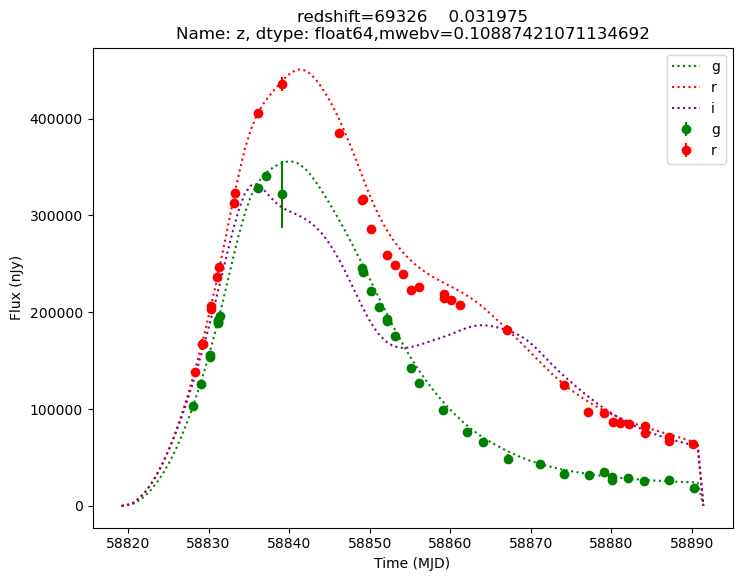

In [29]:
sncosmo_modelname = "salt3"
random_ids = lightcurves_after_quality_cut.id.sample(1).values
colormap = {'g':'g',
            'r':'r',
            'i':'purple',}

for random_id in random_ids:
    # Extract the row for this object.
    # lc = lightcurves.loc[lightcurves.id==random_id]
    lc = lightcurves_after_quality_cut.loc[lightcurves_after_quality_cut.id==random_id]
    lc = lc.query("lightcurve.detection_flag==True")
    
    if lc["nobs"].values[0] > 0:
        # Unpack the nested columns (filters, mjd, flux, and flux error).
        lc_filters = np.asarray(lc["lightcurve.filter"], dtype=str)
        lc_mjd = np.asarray(lc["lightcurve.mjd"], dtype=float)
        lc_flux = np.asarray(lc["lightcurve.flux"], dtype=float)
        lc_fluxerr = np.asarray(lc["lightcurve.fluxerr"], dtype=float)

        lc_mag = -2.5*np.log10(lc_flux) + 31.4
        lc_magerr = np.absolute(1.086*lc_fluxerr/lc_flux)
        
        plot_lightcurves(
            fluxes=lc_flux,
            times=lc_mjd,
            fluxerrs=lc_fluxerr,
            filters=lc_filters,
            colormap=colormap,
        )
        plt.ylabel('Flux (nJy)')
        plt.title(f"redshift={lc['z']},mwebv={lc['params'].values[0]['mwext.ebv']}")

        model = sncosmo.Model(source=sncosmo_modelname,
                      effects=[sncosmo.F99Dust()],
                      effect_names=['mw'],
                      effect_frames=['obs'])
        pardict = {}
        for p in ['x0','x1','c','t0']:
            pardict[p] = lc['params'].values[0][f'source.{p}']
        pardict['mwebv'] = lc['params'].values[0]['mwext.ebv']
        pardict['z'] = lc['z'].values[0]
        model.update(pardict)
        t = np.linspace(-20,50,100)
        obstime = t*(1+pardict['z'])+pardict['t0']
        for b in 'gri':
            plt.plot(obstime,model.bandflux('lsst'+b,obstime,zp=31.4,zpsys='ab'),label=b,ls=':',color=colormap[b])
        plt.legend()
        plt.show()

        # plot_lightcurves(
        #     fluxes=lc_mag,
        #     times=lc_mjd,
        #     fluxerrs=lc_magerr,
        #     filters=lc_filters,
        # )
        # plt.ylabel('Mag')
        # plt.ylim(plt.ylim()[::-1])
        plt.show()

In [31]:
saltpars = pd.read_csv('results/salt3fit_results.csv')
len(saltpars)

2801

In [32]:
saltpars.columns

Index(['id', 'success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err',
       'x0', 'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err',
       'z_z_cov', 'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
       't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
       't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
       'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
       'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
       'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
       'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
       'mwebv_mwebv_cov'],
      dtype='object')

In [41]:
## make cuts based on salt parameters
saltpar_cuts = (saltpars.x1 > -3) & (saltpars.x1 < 3)
print(np.sum(saltpar_cuts))
saltpar_cuts &= (saltpars.c > -0.2) & (saltpars.c < 0.8)
print(np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.t0_err < 1
print(np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.x1_err < 1
print(np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.c_err < 0.1
print(np.sum(saltpar_cuts))

reduced = saltpars.chisq / saltpars.ndof
p_value = 1 - chi2.cdf(saltpars.chisq, df=saltpars.ndof)

saltpar_cuts &= p_value > 1e-7
print(np.sum(saltpar_cuts))


2695
2582
2542
2539
2522
2516


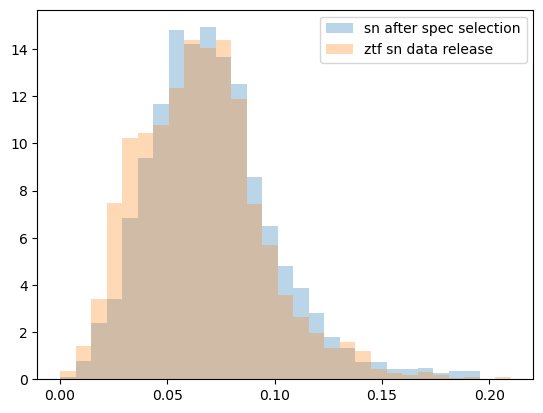

<Figure size 640x480 with 0 Axes>

In [42]:
bins=np.linspace(0,0.21,30)
# plt.hist(lightcurves['z'],bins=bins,alpha=0.3,density=True,label='all sn')
# plt.hist(lightcurves_after_detection['z'],bins=bins,alpha=0.3,density=True,label='sn after detection')
plt.hist(lightcurves_after_spec_selection['z'],bins=bins,alpha=0.3,density=True,label='sn after spec selection')
plt.hist(data.redshift,bins=bins,alpha=0.3,density=True,label='ztf sn data release')
plt.legend()
plt.show()
plt.savefig('paper_figs/z_distr.png')

In [19]:
# data quality flags

# from https://github.com/ZwickyTransientFacility/ztfcosmo/blob/260e136be064708e1238719880ce18844027422e/ztfcosmo/lightcurve.py#L111
# flagout: [list of int or string]
#     flag == 0 means all good, but in details:
    
#     0: no warning 
#     1: flux_err==0 Remove unphysical errors 
#     2: chi2dof>3: Remove extreme outliers 
#     4: cloudy>1: BTS cut 
#     8: infobits>0: BTS cut 16: mag_lim<19.3: Cut applied in Dhawan 2021 
#     32: seeing>3: Cut applied in Dhawan 2021 
#     64: fieldid>879: Recommended IPAC cut 
#     128: moonilf>0.5: Recommended IPAC cut 
#     256: has_baseline>1: Has a valid baseline correction 
#     512: airmass>2: Recommended IPAC cut 
#     1024: flux/flux_err>=5: Nominal detection

/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


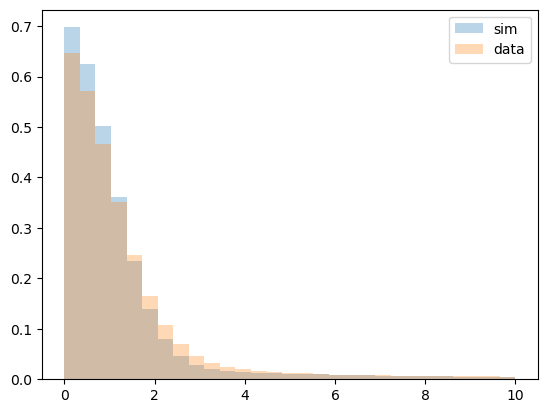

In [43]:
lc_to_plot = lightcurves.loc[lightcurves_after_detection.index]
bins = np.linspace(0,10,30)
plt.hist(lc_to_plot['lightcurve.snr'],bins=bins,alpha=0.3,density=True,label='sim')
lcdata_plot = lcdata.query('lc.flag == 1024 or lc.flag == 0').dropna(subset='lc')
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']
plt.hist(lcdata_plot['lc.snr'],bins=bins,alpha=0.3,density=True,label='data')
plt.legend()
plt.show()

/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


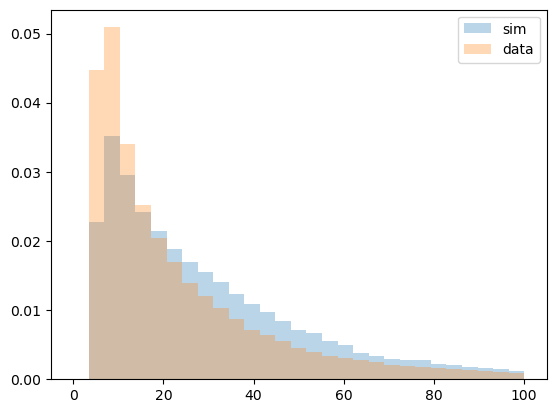

In [44]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]
bins = np.linspace(0,100,30)
plt.hist(lc_to_plot['lightcurve.snr'],bins=bins,alpha=0.3,density=True,label='sim')
lcdata_plot = lcdata.query('lc.flag == 1024 or lc.flag == 0').dropna(subset='lc')
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']
lcdata_plot = lcdata_plot.query('lc.snr > 5').dropna(subset='lc')
plt.hist(lcdata_plot['lc.snr'],bins=bins,alpha=0.3,density=True,label='data')
plt.legend()
plt.show()

/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


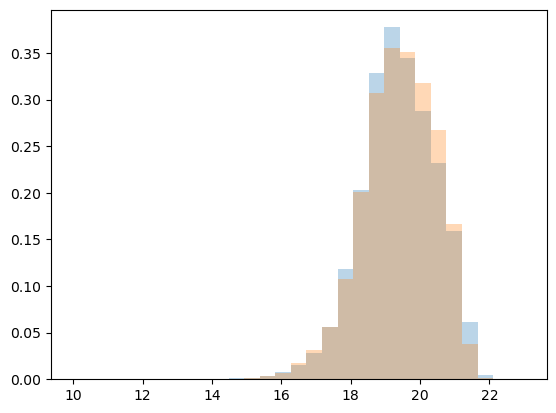

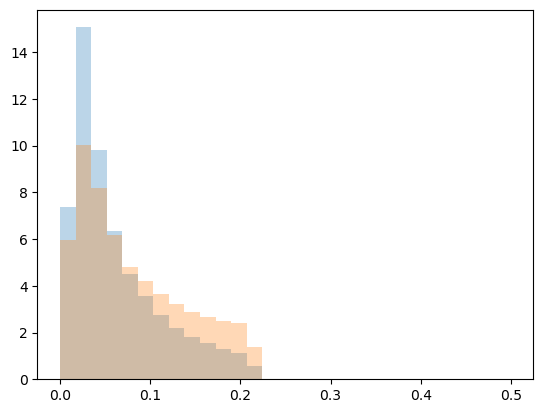

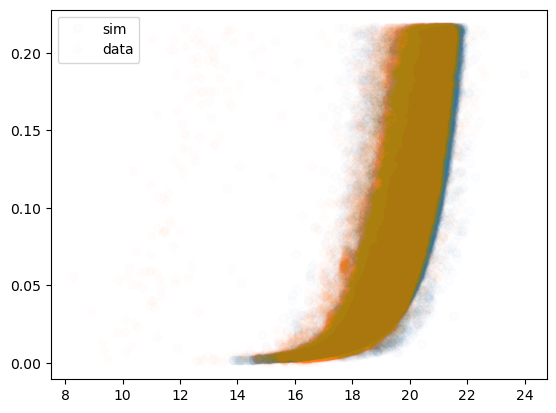

In [45]:
def convert_flux_to_mag(flux,fluxerr,zp=0.):
    mag = -2.5*np.log10(flux) + zp
    magerr = 2.5/np.log(10.)*fluxerr/flux
    return mag,magerr

lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]
bins = np.linspace(10,23,30)
lcdata_plot = lcdata.query('lc.flag == 1024 or lc.flag == 0').dropna(subset='lc')
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']
lcdata_plot = lcdata_plot.query('lc.snr > 5').dropna(subset='lc')
lcdata_mag,lcdata_magerr = convert_flux_to_mag(lcdata_plot['lc.flux'],lcdata_plot['lc.flux_err'],zp=30.)
lc_to_plot_mag,lc_to_plot_magerr = convert_flux_to_mag(lc_to_plot['lightcurve.flux'],lc_to_plot['lightcurve.fluxerr'],zp=31.4)
plt.hist(lc_to_plot_mag,bins=bins,alpha=0.3,density=True)
plt.hist(lcdata_mag,bins=bins,alpha=0.3,density=True)
plt.show()
bins = np.linspace(0,0.5,30)
plt.hist(lc_to_plot_magerr,bins=bins,alpha=0.3,density=True)
plt.hist(lcdata_magerr,bins=bins,alpha=0.3,density=True)
plt.show()
plt.plot(lc_to_plot_mag,lc_to_plot_magerr,'o',alpha=0.01,label='sim')
plt.plot(lcdata_mag,lcdata_magerr,'o',alpha=0.01,label='data')
plt.legend()
plt.show()

/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


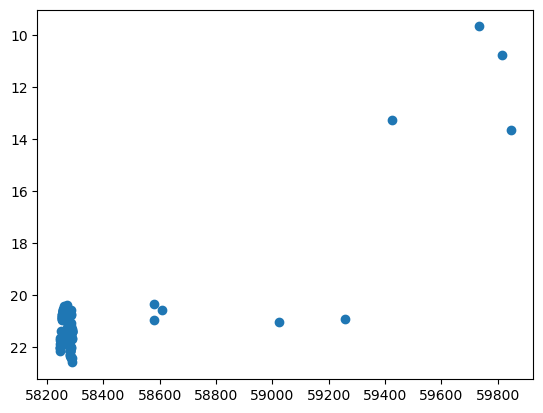

ZTF18aashtth
             mjd filter          flux      flux_err    ZP  flag       mag  \
0    58246.33757   ztfg  5.008439e+03  8.449795e+02  30.0  1024  20.75074   
1    58246.36031   ztfg  5.797578e+03  7.928762e+02  30.0  1024  20.59188   
..           ...    ...           ...           ...   ...   ...       ...   
137  59816.20694   ztfg  1.796189e+08  1.232231e+06  30.0  1024   9.36412   
138  59847.16666   ztfg  1.267507e+07  1.602516e+06  30.0  1024  12.24262   

     mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0    0.18318       635  32.0    167.23896    43.98385        1.0            0   
1    0.14849       635  32.0    167.23896    43.98385        1.0            0   
..       ...       ...   ...          ...         ...        ...          ...   
137  0.00745       635  32.0    167.23896    43.98385        1.0            0   
138  0.13727       635  32.0    167.23896    43.98385        1.0            0   

            snr  
0      5.927291  
1

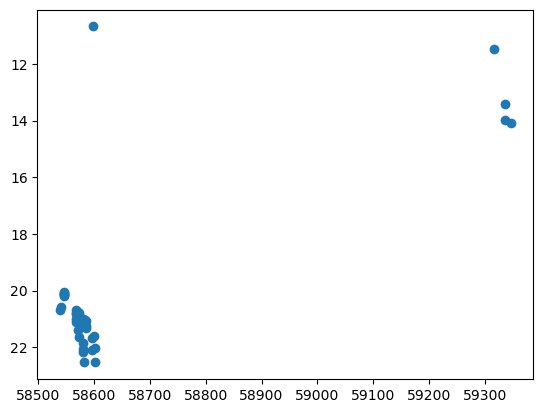

ZTF19aaksrgj
            mjd filter          flux      flux_err    ZP  flag       mag  \
0   58539.35573   ztfr  1.921365e+04  1.685139e+03  30.0  1024  19.29098   
1   58540.35671   ztfg  2.152612e+04  7.051787e+02  30.0  1024  19.16759   
..          ...    ...           ...           ...   ...   ...       ...   
40  59335.23204   ztfg  9.258658e+06  1.584806e+06  30.0  1024  12.58363   
41  59346.31597   ztfg  8.449574e+06  1.602285e+06  30.0  1024  12.68291   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.09522       474  60.0   1029.44408   139.55419        1.0            0   
1   0.03557       525   2.0     22.28824    62.57741        1.0            0   
..      ...       ...   ...          ...         ...        ...          ...   
40  0.18585       525   2.0     22.28824    62.57741        1.0            0   
41  0.20589       525   2.0     22.28824    62.57741        1.0            0   

          snr  
0   11.401815  
1   30.525769  
.

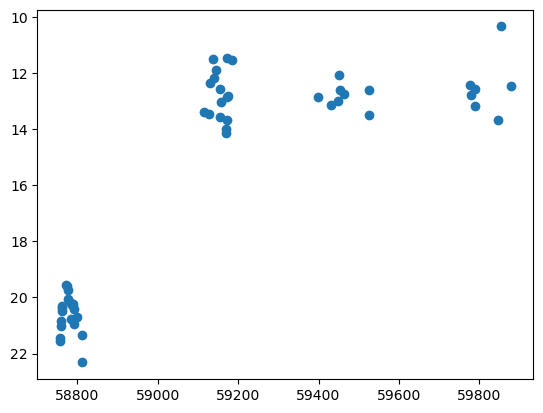

ZTF19accmxtw
            mjd filter          flux      flux_err    ZP  flag       mag  \
0   58757.26645   ztfi  9.443234e+03  1.312251e+03  30.0  1024  20.06220   
1   58758.21080   ztfg  8.818193e+03  6.746138e+02  30.0  1024  20.13655   
..          ...    ...           ...           ...   ...   ...       ...   
49  59854.30641   ztfr  2.638430e+08  7.961178e+06  30.0  1024   8.94664   
50  59878.13013   ztfr  3.765777e+07  1.394651e+06  30.0  1024  11.06036   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.15088       597  29.0   -326.73539   225.93636    1.19402            0   
1   0.08306       597  29.0     81.34453    53.43814    1.00000            0   
..      ...       ...   ...          ...         ...        ...          ...   
49  0.03276       597  29.0   -406.89933    81.82750    1.16814            0   
50  0.04021       597  29.0   -406.89933    81.82750    1.16814            0   

          snr  
0    7.196210  
1   13.071468  
.

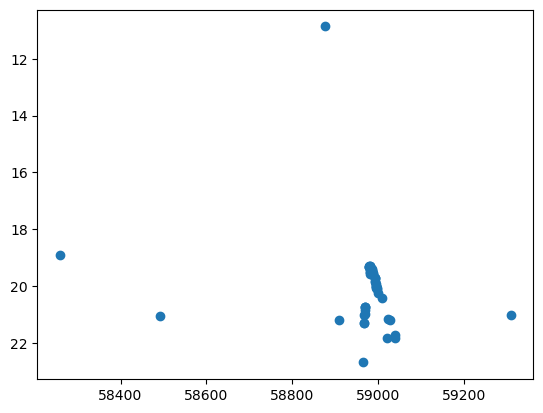

ZTF20aaxahpk
            mjd filter         flux     flux_err    ZP  flag       mag  \
0   58259.17374   ztfg  98462.52214  19616.43048  30.0  1024  17.51682   
1   58492.48949   ztfr  13727.88280   2446.91805  30.0  1024  19.65599   
..          ...    ...          ...          ...   ...   ...       ...   
46  59038.17892   ztfr   7387.45796   1025.23483  30.0  1024  20.32876   
47  59308.34090   ztfg  14125.28312   2308.68883  30.0  1024  19.62501   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.21631       713  33.0    255.41977   122.83969    1.03982            0   
1   0.19353       713  33.0   -128.40675    56.83178    1.04531            0   
..      ...       ...   ...          ...         ...        ...          ...   
46  0.15068       713  33.0   -128.40675    56.83178    1.04531            0   
47  0.17746       713  33.0    255.41977   122.83969    1.03982            0   

         snr  
0   5.019390  
1   5.610275  
..       ...  
4

In [46]:
# check about the outliers in data
maglim = mag2flux(11)
idx = lcdata_plot.query(f'lc.flux > {maglim}').dropna(subset='lc').index
outlier = lcdata_plot.loc[idx]
for i in range(0,np.min([10,len(outlier)])):
    plt.plot(outlier.iloc[i]['lc']['mjd'],flux2mag(outlier.iloc[i]['lc']['flux']),'o')
    plt.ylim(plt.ylim()[::-1])
    plt.show()
    print(outlier.iloc[i]['ztfname'])
    print(outlier.iloc[i]['lc'])

/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


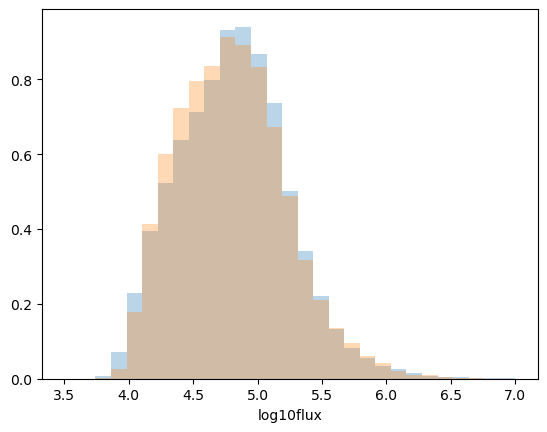

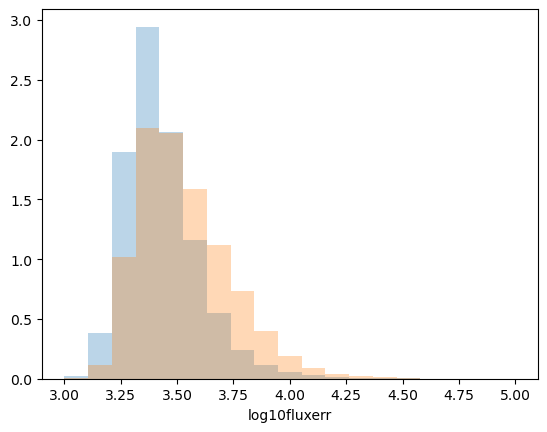

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_31595/4094580003.py:43: UserWarning: The following kwargs were not used by contour: 'label'
  CS = plt.contour(lcsim_x_plot.T,lcsim_y_plot.T,lcsim_count,alpha=0.5,label='sim',levels=10,colors='C0')
/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_31595/4094580003.py:44: UserWarning: The following kwargs were not used by contour: 'label'
  CS = plt.contour(lcdata_x_plot.T,lcdata_y_plot.T,lcdata_count,alpha=0.5,label='data',levels=10,colors='C1')


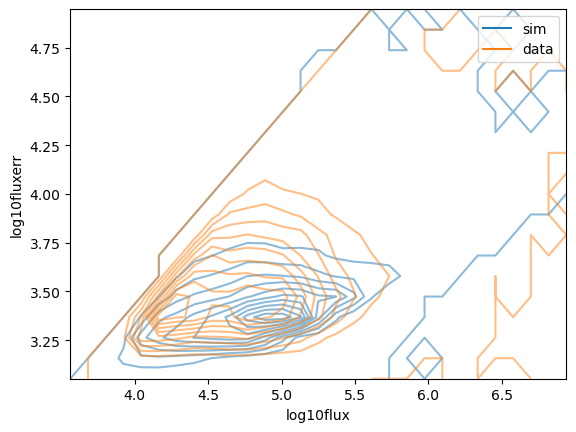

In [47]:
def convert_flux_to_njy(flux,fluxerr,zp=0.):
    zp_njy = 31.4
    #-2.5*log10(flux_njy) + zp_njy = -2.5*log10(flux) + zp
    flux_njy = flux*np.power(10., -0.4*(zp-zp_njy))
    fluxerr_njy = fluxerr*np.power(10., -0.4*(zp-zp_njy))         
    return flux_njy,fluxerr_njy

lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]
lcdata_plot = lcdata.query('lc.flag == 1024 or lc.flag == 0').dropna(subset='lc')
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']
lcdata_plot = lcdata_plot.query('lc.snr > 5').dropna(subset='lc')
lcdata_flux_njy,lcdata_fluxerr_njy = convert_flux_to_njy(lcdata_plot['lc.flux'],lcdata_plot['lc.flux_err'],zp=30.)

lcdata_logflux = np.log10(lcdata_flux_njy)
lcdata_logfluxerr = np.log10(lcdata_fluxerr_njy)
lcsim_logflux = np.log10(lc_to_plot['lightcurve.flux'])
lcsim_logfluxerr = np.log10(lc_to_plot['lightcurve.fluxerr'])
logbins_flux = np.linspace(3.5,7,30)
logbins_fluxerr = np.linspace(3,5,20)

plt.hist(lcsim_logflux,bins=logbins_flux,alpha=0.3,density=True)
plt.hist(lcdata_logflux,bins=logbins_flux,alpha=0.3,density=True)
plt.xlabel("log10flux")
plt.show()

plt.hist(lcsim_logfluxerr,bins=logbins_fluxerr,alpha=0.3,density=True)
plt.hist(lcdata_logfluxerr,bins=logbins_fluxerr,alpha=0.3,density=True)
plt.xlabel("log10fluxerr")
plt.show()

lcsim_count,lcsim_x_edges,lcsim_y_edges, _ = stats.binned_statistic_2d(lcsim_logflux,lcsim_logfluxerr,
                                             np.ones(len(lcsim_logflux)),
                                             statistic='sum',bins=[logbins_flux,logbins_fluxerr])
lcdata_count,lcdata_x_edges,lcdata_y_edges,_ = stats.binned_statistic_2d(lcdata_logflux,lcdata_logfluxerr,
                                         np.ones(len(lcdata_logflux)),
                                         statistic='sum',bins=[logbins_flux,logbins_fluxerr])
lcsim_x = 0.5* (lcsim_x_edges[:-1]+lcsim_x_edges[1:])
lcsim_y = 0.5* (lcsim_y_edges[:-1]+lcsim_y_edges[1:])
lcdata_x = 0.5* (lcdata_x_edges[:-1]+lcdata_x_edges[1:])
lcdata_y = 0.5* (lcdata_y_edges[:-1]+lcdata_y_edges[1:])
lcsim_x_plot,lcsim_y_plot = np.meshgrid(lcsim_x, lcsim_y)
lcdata_x_plot,lcdata_y_plot = np.meshgrid(lcdata_x, lcdata_y)
CS = plt.contour(lcsim_x_plot.T,lcsim_y_plot.T,lcsim_count,alpha=0.5,label='sim',levels=10,colors='C0')
CS = plt.contour(lcdata_x_plot.T,lcdata_y_plot.T,lcdata_count,alpha=0.5,label='data',levels=10,colors='C1')
proxies = [Line2D([],[],color=c) for c in ['C0','C1']]
plt.legend(proxies,['sim', 'data'])
plt.xlabel('log10flux')
plt.ylabel('log10fluxerr')
plt.show()

/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/tdastro/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


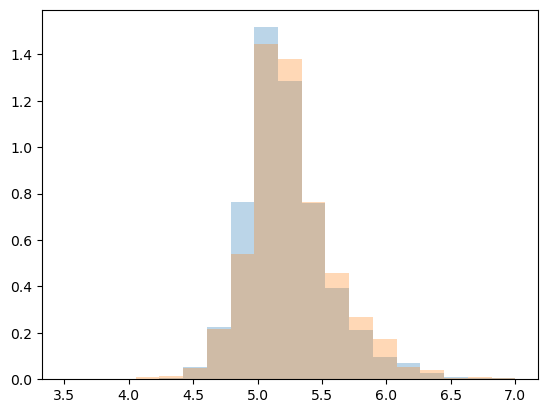

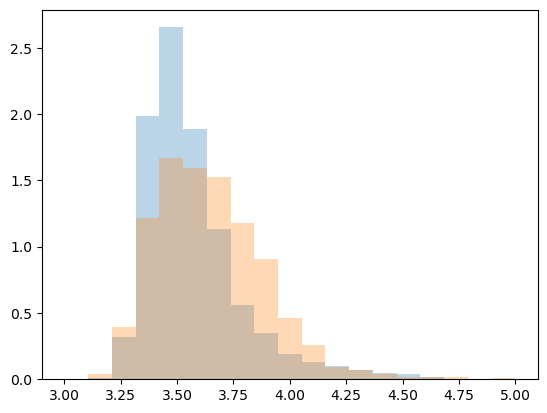

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_31595/2052247313.py:43: UserWarning: The following kwargs were not used by contour: 'label'
  CS = plt.contour(lcsim_x_plot.T,lcsim_y_plot.T,lcsim_count,alpha=0.5,label='sim',levels=10,colors='C0')
/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_31595/2052247313.py:44: UserWarning: The following kwargs were not used by contour: 'label'
  CS = plt.contour(lcdata_x_plot.T,lcdata_y_plot.T,lcdata_count,alpha=0.5,label='data',levels=10,colors='C1')


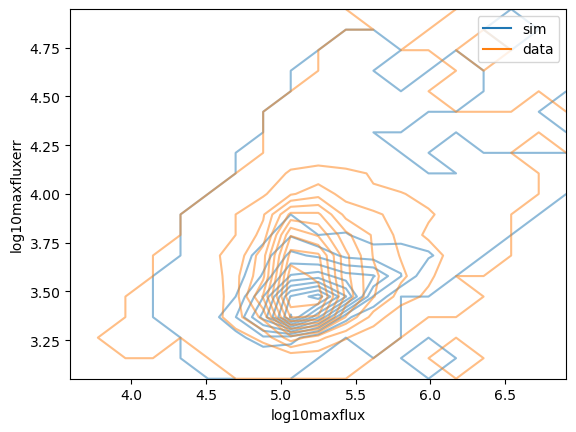

In [48]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]
lcdata_plot = lcdata.query('lc.flag == 1024 or lc.flag == 0').dropna(subset='lc')
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']
lcdata_plot = lcdata_plot.query('lc.snr > 5').dropna(subset='lc')
def get_maxflux_and_err(flux,fluxerr):
    idx = np.argmax(flux)
    maxflux = flux[idx]
    maxfluxerr = fluxerr[idx]
    return {"maxflux":maxflux,"maxfluxerr":maxfluxerr}
lcdata_maxflux = lcdata_plot.reduce(get_maxflux_and_err,"lc.flux","lc.flux_err")
lcdata_maxflux_njy,lcdata_maxfluxerr_njy = convert_flux_to_njy(lcdata_maxflux["maxflux"],lcdata_maxflux["maxfluxerr"],
                                                               zp=30.)

lcdata_logmaxflux = np.log10(lcdata_maxflux_njy)
lcdata_logmaxfluxerr = np.log10(lcdata_maxfluxerr_njy)

lcsim_maxflux = lc_to_plot.reduce(get_maxflux_and_err,"lightcurve.flux","lightcurve.fluxerr")
lcsim_logmaxflux = np.log10(lcsim_maxflux["maxflux"])
lcsim_logmaxfluxerr = np.log10(lcsim_maxflux["maxfluxerr"])
logbins_flux = np.linspace(3.5,7,20)
logbins_fluxerr = np.linspace(3,5,20)

plt.hist(lcsim_logmaxflux,bins=logbins_flux,alpha=0.3,density=True)
plt.hist(lcdata_logmaxflux,bins=logbins_flux,alpha=0.3,density=True)
plt.show()

plt.hist(lcsim_logmaxfluxerr,bins=logbins_fluxerr,alpha=0.3,density=True)
plt.hist(lcdata_logmaxfluxerr,bins=logbins_fluxerr,alpha=0.3,density=True)
plt.show()

lcsim_count,lcsim_x_edges,lcsim_y_edges, _ = stats.binned_statistic_2d(lcsim_logmaxflux,lcsim_logmaxfluxerr,
                                             np.ones(len(lcsim_logmaxflux)),
                                             statistic='sum',bins=[logbins_flux,logbins_fluxerr])
lcdata_count,lcdata_x_edges,lcdata_y_edges,_ = stats.binned_statistic_2d(lcdata_logmaxflux,lcdata_logmaxfluxerr,
                                         np.ones(len(lcdata_logmaxflux)),
                                         statistic='sum',bins=[logbins_flux,logbins_fluxerr])
lcsim_x = 0.5* (lcsim_x_edges[:-1]+lcsim_x_edges[1:])
lcsim_y = 0.5* (lcsim_y_edges[:-1]+lcsim_y_edges[1:])
lcdata_x = 0.5* (lcdata_x_edges[:-1]+lcdata_x_edges[1:])
lcdata_y = 0.5* (lcdata_y_edges[:-1]+lcdata_y_edges[1:])
lcsim_x_plot,lcsim_y_plot = np.meshgrid(lcsim_x, lcsim_y)
lcdata_x_plot,lcdata_y_plot = np.meshgrid(lcdata_x, lcdata_y)
CS = plt.contour(lcsim_x_plot.T,lcsim_y_plot.T,lcsim_count,alpha=0.5,label='sim',levels=10,colors='C0')
CS = plt.contour(lcdata_x_plot.T,lcdata_y_plot.T,lcdata_count,alpha=0.5,label='data',levels=10,colors='C1')
proxies = [Line2D([],[],color=c) for c in ['C0','C1']]
plt.legend(proxies,['sim', 'data'])
plt.xlabel('log10maxflux')
plt.ylabel('log10maxfluxerr')
plt.show()

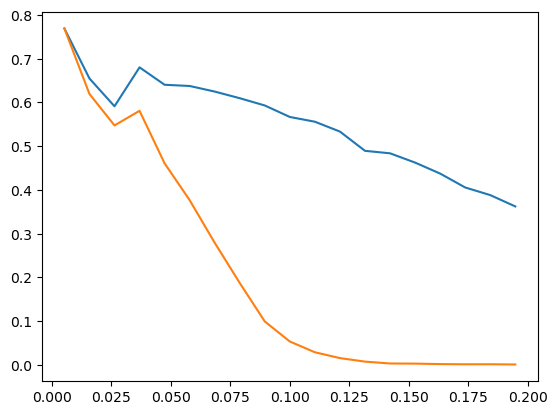

In [49]:
bins = np.linspace(0,0.2,20)
zbefore,bin_edges,_ = stats.binned_statistic(lightcurves['z'],np.ones(len(lightcurves)), statistic='sum', bins=bins)
zafter,bin_edges,_ =  stats.binned_statistic(lightcurves_after_detection['z'], np.ones(len(lightcurves_after_detection)), statistic='sum', bins=bins)
zafter_spec,bin_edges,_ =  stats.binned_statistic(lightcurves_after_spec_selection['z'], np.ones(len(lightcurves_after_spec_selection)), statistic='sum', bins=bins)
plt.plot((bin_edges[:-1] + bin_edges[1:])/2.,zafter/zbefore)
plt.plot((bin_edges[:-1] + bin_edges[1:])/2.,zafter_spec/zbefore)

In [50]:
sim_all_x1 = [lightcurves.loc[i]['params']['source.x1'] for i in lightcurves.index]
sim_all_c = [lightcurves.loc[i]['params']['source.c'] for i in lightcurves.index]

In [53]:
sim_x1 = [lightcurves_after_quality_cut.loc[i]['params']['source.x1'] for i in lightcurves_after_quality_cut.index]
sim_c = [lightcurves_after_quality_cut.loc[i]['params']['source.c'] for i in lightcurves_after_quality_cut.index]

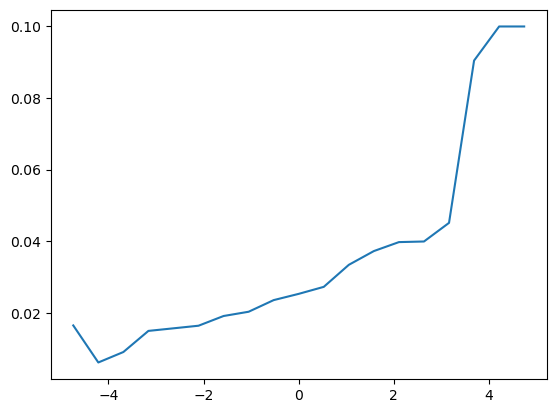

In [55]:
bins = np.linspace(-5,5,20)
x1before,bin_edges,_ = stats.binned_statistic(sim_all_x1,np.ones(len(lightcurves)), statistic='sum', bins=bins)
x1after,bin_edges,_ =  stats.binned_statistic(sim_x1, np.ones(len(lightcurves_after_quality_cut)), statistic='sum', bins=bins)
plt.plot((bin_edges[:-1] + bin_edges[1:])/2.,x1after/x1before)
plt.savefig('paper_figs/x1_selection.png')

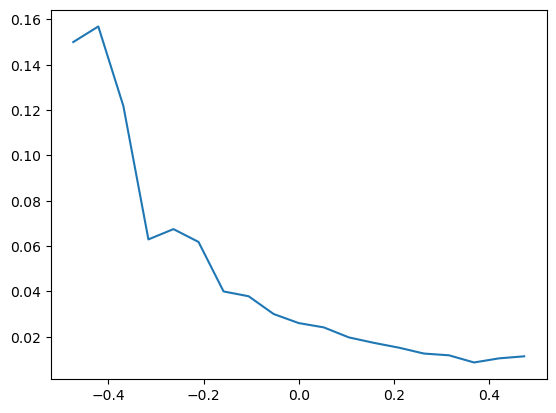

In [56]:
bins = np.linspace(-0.5,0.5,20)
cbefore,bin_edges,_ = stats.binned_statistic(sim_all_c,np.ones(len(lightcurves)), statistic='sum', bins=bins)
cafter,bin_edges,_ =  stats.binned_statistic(sim_c, np.ones(len(lightcurves_after_quality_cut)), statistic='sum', bins=bins)
plt.plot((bin_edges[:-1] + bin_edges[1:])/2.,cafter/cbefore)
plt.savefig('paper_figs/c_selection.png')

Text(0.5, 1.0, 'reduced chisq')

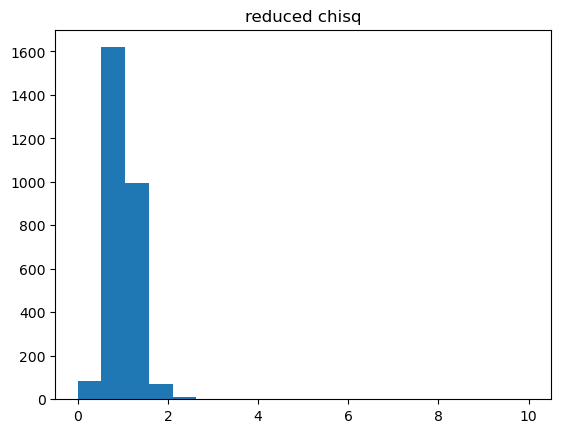

In [58]:
result_df = saltpars
idx = result_df.ndof > 0
result_df = result_df[idx]
plt.hist(result_df[idx].chisq/result_df[idx].ndof,bins=np.linspace(0,10,20))
plt.title('reduced chisq')

In [60]:
lc_to_fit = lightcurves_after_quality_cut

Text(0.5, 1.0, 'x1-sim_x1')

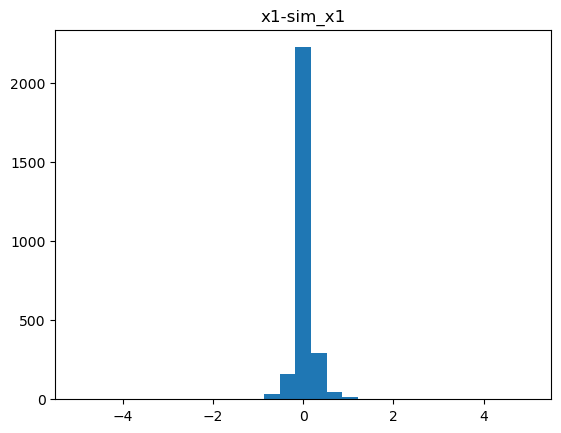

In [63]:
x1 = result_df['x1']
sim_x1 = [lc_to_fit.loc[i]['params']['source.x1'] for i in result_df.id]
plt.hist(x1-sim_x1,bins=np.linspace(-5,5,30))
plt.title('x1-sim_x1')

Text(0.5, 1.0, 'c-sim_c')

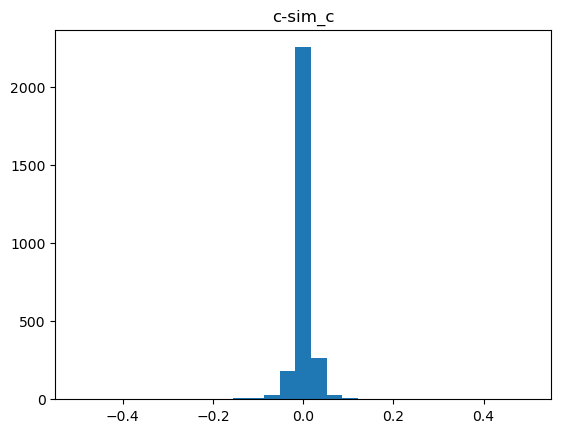

In [64]:
c = result_df['c']
sim_c = [lc_to_fit.loc[i]['params']['source.c'] for i in result_df.id]
plt.hist(c-sim_c,bins=np.linspace(-0.5,0.5,30))
plt.title('c-sim_c')

Text(0.5, 1.0, 'x0-sim_x0')

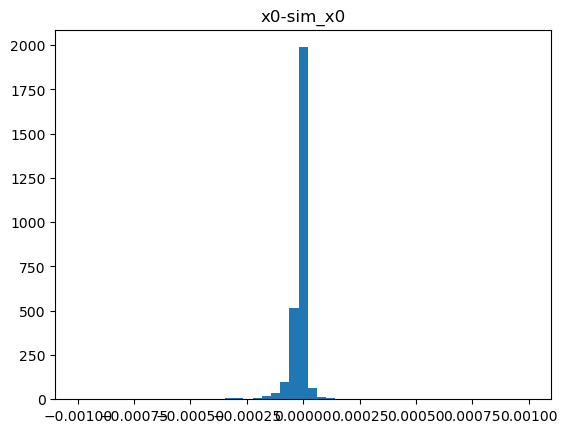

In [65]:
x0 = result_df['x0']
sim_x0 = [lc_to_fit.loc[i]['params']['source.x0'] for i in result_df.id]
plt.hist(x0-sim_x0,bins=np.linspace(-1.e-3,1.e-3))
plt.title('x0-sim_x0')

Text(0.5, 1.0, 'log(x0)-log(sim_x0)')

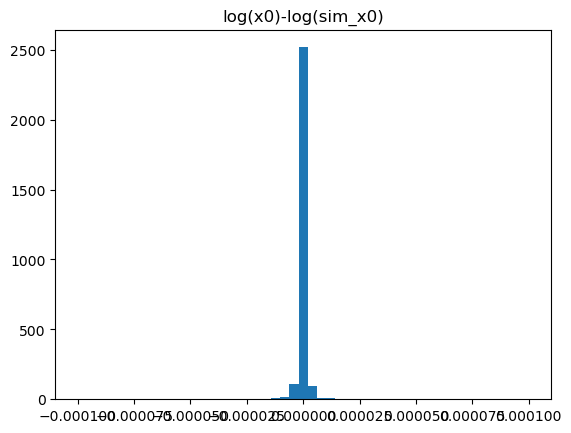

In [66]:
x0 = result_df['t0']
sim_x0 = [lc_to_fit.loc[i]['params']['source.t0'] for i in result_df.id]
plt.hist(np.log10(x0/sim_x0),bins=np.linspace(-1.e-4,1e-4))
plt.title('log(x0)-log(sim_x0)')

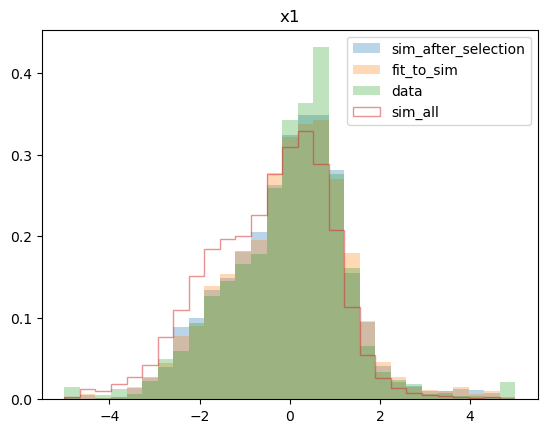

In [67]:
bins=np.linspace(-5,5,30)
plt.hist(sim_x1,bins=bins,alpha=0.3,density=True,label='sim_after_selection')
plt.hist(x1,bins=bins,alpha=0.3,density=True,label='fit_to_sim')
plt.hist(data.x1,bins=bins,alpha=0.3,density=True,label='data')
plt.hist(sim_all_x1,bins=bins,alpha=0.5,density=True,label='sim_all',histtype='step')
plt.legend()
plt.title('x1')
plt.savefig('paper_figs/x1_distr.png')

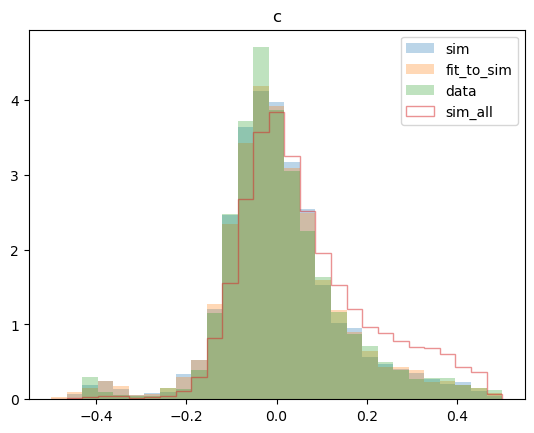

In [68]:
bins=np.linspace(-0.5,0.5,30)
plt.hist(sim_c,bins=bins,alpha=0.3,density=True,label='sim')
plt.hist(c,bins=bins,alpha=0.3,density=True,label='fit_to_sim')
plt.hist(data.c,bins=bins,alpha=0.3,density=True,label='data')
plt.hist(sim_all_c,bins=bins,alpha=0.5,density=True,label='sim_all',histtype='step')
plt.legend()
plt.title('c')
plt.savefig('paper_figs/c_distr.png')

Text(0.5, 1.0, 'host mass')

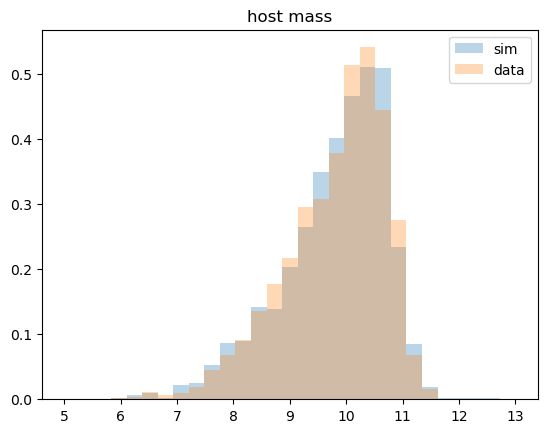

In [70]:
hostmass = [lc_to_fit.loc[i]['params']['host.hostmass'] for i in result_df.id]
bins = np.linspace(5,13,30)
plt.hist(hostmass,bins=bins,alpha=0.3,density=True,label='sim')
plt.hist(data.mass,bins=bins,alpha=0.3,density=True,label='data')
plt.legend()
plt.title('host mass')

2510
3163


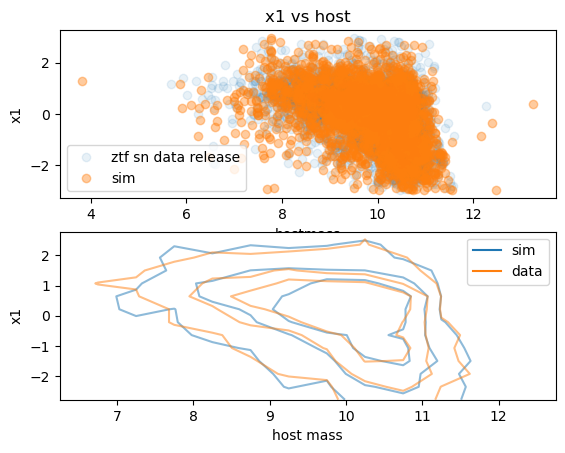

In [71]:
idx = np.array((x1 > -3.) & (x1 < 3.) & (c > -0.3) & (c < 0.3))
data_idx = np.array((data.x1 > -3.) & (data.x1 < 3.) & (data.c > -0.3) & (data.c < 0.3))
print(np.sum(idx))
print(np.sum(data_idx))

fig = plt.figure()
plt.subplot(2,1,1)
plt.plot(data[data_idx].mass,data[data_idx].x1,'o',label='ztf sn data release',alpha=0.1)
plt.plot(np.array(hostmass)[idx],np.array(x1)[idx],'o',label='sim',alpha=0.4)
plt.xlabel('hostmass')
plt.ylabel('x1')
plt.legend()
plt.title('x1 vs host')
# plt.show()

plt.subplot(2,1,2)
bins_x1 = np.linspace(-3,3,15)
bins_hostmass = np.linspace(6,13,15)

data_plot = data[data_idx]
sim_host = np.array(hostmass)[idx]
sim_x1 = np.array(x1)[idx]

binwidth_host = bins_hostmass[1]-bins_hostmass[0]
binwidth_x1 = bins_x1[1]-bins_x1[0]

sim_count,sim_x_edges,sim_y_edges, _ = stats.binned_statistic_2d(sim_host,sim_x1,
                                             np.ones(len(sim_host)),
                                             statistic='sum',bins=[bins_hostmass,bins_x1])
data_count,data_x_edges,data_y_edges,_ = stats.binned_statistic_2d(data_plot.mass,data_plot.x1,
                                         np.ones(len(data_plot.mass)),
                                         statistic='sum',bins=[bins_hostmass,bins_x1])
sim_x = 0.5* (sim_x_edges[:-1]+sim_x_edges[1:])
sim_y = 0.5* (sim_y_edges[:-1]+sim_y_edges[1:])
data_x = 0.5* (data_x_edges[:-1]+data_x_edges[1:])
data_y = 0.5* (data_y_edges[:-1]+data_y_edges[1:])
sim_x_plot,sim_y_plot = np.meshgrid(sim_x, sim_y)
data_x_plot,data_y_plot = np.meshgrid(data_x, data_y)
CS = plt.contour(sim_x_plot.T,sim_y_plot.T,sim_count/np.sum(sim_count)/binwidth_host/binwidth_x1,alpha=0.5,levels=[0.01,0.05,0.1],colors='C0')
CS = plt.contour(data_x_plot.T,data_y_plot.T,data_count/np.sum(data_count)/binwidth_host/binwidth_x1,alpha=0.5,levels=[0.01,0.05,0.1],colors='C1')
proxies = [Line2D([],[],color=c) for c in ['C0','C1']]
plt.legend(proxies,['sim', 'data'])
plt.xlabel('host mass')
plt.ylabel('x1')
plt.show()
fig.savefig('paper_figs/host_x1.png')

Effects maybe simulated
ZTF Photometry "pocket effect" (Fig 2 of ZTF DR2 Overview paper https://arxiv.org/pdf/2409.04346)
<img src="figs/pocket_effect.png" width="400" height="300">
